In [113]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt 

# Analyzing the effect of including telematics data

Below we have the same set of data evaluated with an algoritm that **took telematics data into account** 

* traditional_w_telematics_risk_df 

as well as a model that **did not** take telematics data into account 

* traditional_risk_df

By taking a look at the risk scores produced from each algorithm we can see the effect that driving habits had on the premiums 

I have chosen a simple dynamic pricing model 

$$ Premium = BaseRate + \alpha*Risk\_Factor$$

Where 

$$ BaseRate = \$300, \alpha = \$200 $$

so at maximum a customer can be charged $500 when deemed a large risk. And so

$$\Delta Risk\_Factor \rightarrow \Delta Premium$$

Lets see what effect taking telematics data had on premiums for good drivers, which account for a majority of the dataset

In [129]:
traditional_risk_df = pd.read_csv("../data/preprocessed_data/processed_dataset_traditional_with_risk_scores_10000.csv")
traditional_w_telematics_risk_df = pd.read_csv("../data/preprocessed_data/processed_dataset_traditional+telematics_with_risk_scores_10000.csv")

In [130]:
traditional_risk_df.columns

Index(['Unnamed: 0', 'Cost_claims_year', 'N_claims_year', 'N_claims_history',
       'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Power',
       'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length',
       'Weight', 'age', 'years_driving', 'Month', 'Claim_this_month',
       'avg_speed', 'hard_brakes', 'hard_accel', 'speeding_events', 'trip_len',
       'risk_factor', 'premium'],
      dtype='object')

## Lets create 1 dataset that has all of the variables of interest

In [131]:
# tradiational risk factor
col1 = traditional_risk_df["risk_factor"]

# risk factor taking into account telematics data
col2 = traditional_w_telematics_risk_df["risk_factor"]

# tradiational premium
prem1 = traditional_risk_df["premium"]

# Premium taking into account driving behaviour
prem2 = traditional_w_telematics_risk_df["premium"]

# Create a new dataframe risk factors, premiums and driving behaviour
new_df = pd.DataFrame({
    "risk_factor_trad": col1,
    "risk_factor_trad_and_telematic": col2,
    "bad_driver":traditional_risk_df["Claim_this_month"],
    'speeding_events': traditional_risk_df['speeding_events'],
    'hard_accel': traditional_risk_df['hard_accel'],
    'hard_brakes': traditional_risk_df['hard_brakes'],
    "prem_trad": prem1,
    "prem_trad_and_telematic": prem2,
    "prem_trad_telematic_minus_trad": prem2 - prem1  # Calculate difference in premiums (df2 - df1)
})

# Good Vs Bad driver behaviour

In the dataset below a value of 0 in the bad_driver column indicates a "Good" driver, while a value of 1 indicates a "Bad" driver. Good and Bad driver behaviour was determined by weather a claim was filed by the driver during a given month. Driver behaviour was simulated via poisson distribution sampling with differrent means to distinguish between the two.

## Good driver behaviour
* For Good drivers, indicated by "bad_driver"==0, we can see that pretty consistently the risk factors drop when taking into account the driver behaviour, leading to a decreace in premium. Obseerve how here even good drivers are allowed occasional speeding and 'hard' events. So long as they are statistically below the bad driver baseline


In [132]:
new_df[new_df["bad_driver"]==0].sample(10)

,risk_factor_trad,risk_factor_trad_and_telematic,bad_driver,speeding_events,hard_accel,hard_brakes,prem_trad,prem_trad_and_telematic,prem_trad_telematic_minus_trad
698,0.768017,0.004033,0,0,1,1,453.603434,300.806694,-152.796740
24007,0.124709,0.002635,0,0,0,1,324.941750,300.526949,-24.414801
9644,0.128935,0.013616,0,1,2,0,325.787023,302.723234,-23.063790
2482,0.516152,0.006650,0,3,0,2,403.230496,301.329947,-101.900549
2380,0.112304,0.011636,0,2,2,0,322.460792,302.327254,-20.133537
77334,0.155248,0.000393,0,0,0,0,331.049557,300.078512,-30.971045
30717,0.871699,0.845236,0,0,3,3,474.339801,469.047142,-5.292660
83458,0.122776,0.000824,0,1,1,2,324.555215,300.164718,-24.390498
105035,0.139379,0.010674,0,2,0,0,327.875701,302.134802,-25.740899
4404,0.179532,0.002589,0,1,0,2,335.906377,300.517802,-35.388575


## Bad driver behaviour
* For Bad drivers, indicated by "bad_driver"==1, we can see that pretty consistently the risk factors increace when taking into account the driver behaviour, leading to a increace in premium on average. Note the markedly higher number of adverse behavioural events

In [135]:
new_df[new_df["bad_driver"]==1].sample(10)

,risk_factor_trad,risk_factor_trad_and_telematic,bad_driver,speeding_events,hard_accel,hard_brakes,prem_trad,prem_trad_and_telematic,prem_trad_telematic_minus_trad
25006,0.650454,0.998108,1,1,3,3,430.090827,499.621689,69.530862
96161,0.431941,0.999900,1,5,4,2,386.388225,499.979982,113.591757
115041,0.908078,0.989439,1,3,3,3,481.615618,497.887721,16.272104
10734,0.534328,0.992709,1,1,5,2,406.865593,498.541798,91.676205
36324,0.551412,0.963468,1,0,0,2,410.282392,492.693592,82.411200
33924,0.380562,0.312473,1,0,2,0,376.112458,362.494593,-13.617864
99833,0.954492,0.957296,1,2,2,0,490.898486,491.459142,0.560656
97986,0.671690,0.993863,1,1,1,5,434.337919,498.772514,64.434595
33898,0.471838,0.987802,1,3,3,4,394.367696,497.560423,103.192727
104474,0.997352,0.998456,1,0,3,2,499.470384,499.691237,0.220852


# Visualizing the differencee
If we take a look at the difference in premiums between good (Blue) and bad (Orange) drivers once we take into account driver behaviour, we can see that on average the price paid per month by good drivers drops (blue distribution shifts leftward). Although some good drivers are still paying exorbidantly high prices, this could be due to other factors for that individual in the algorithm, such as claims ratio (number of claims over the life of the policy.)

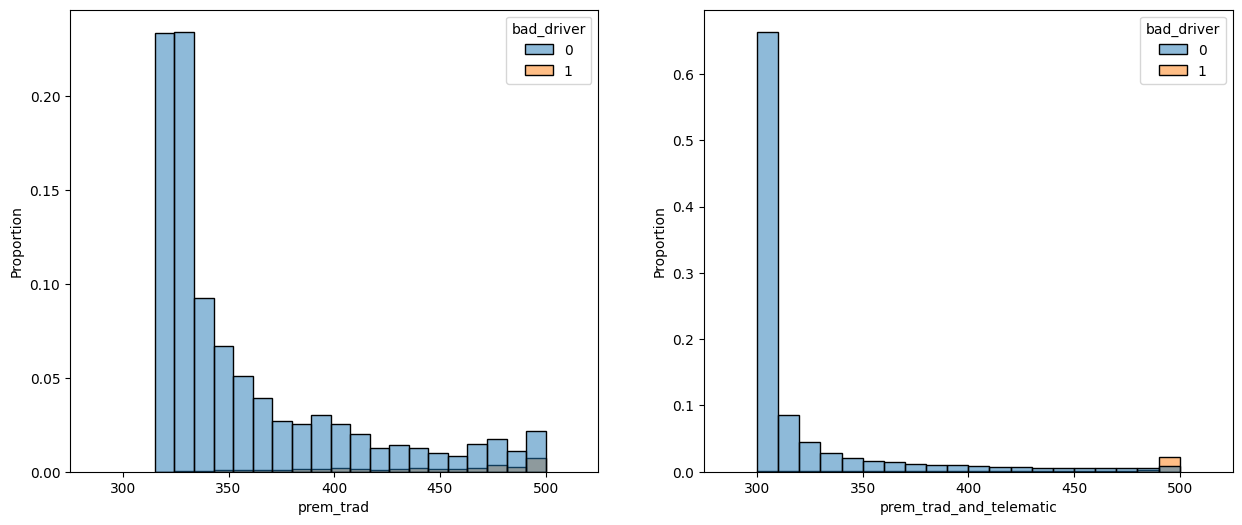

In [145]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 1 row, 1 column, 1 subplot
sns.histplot(data=new_df, ax=axes[0], x="prem_trad", hue="bad_driver", stat='proportion', bins=20)
sns.histplot(data=new_df, ax=axes[1], x="prem_trad_and_telematic", hue="bad_driver", stat='proportion', bins=20)
axes[0].set_xlim(275, 525)
axes[1].set_xlim(275, 525)
plt.show()

# Quantifying the difference
We can see visually that the distribution for good drivers moves leftwards, showing a decreace in premium, but on average, how much do good drivers save over the course of a month? On average they save \\$37 a month. while bad drivers pay \\$37 more.

In [143]:
# Calculating the average payment of good drivers
good_driver_df = new_df[new_df["bad_driver"]==0]
print(good_driver_df["prem_trad"].mean().round(2))
print(good_driver_df["prem_trad_and_telematic"].mean().round(2),"\n")
average_good_driver_savings = good_driver_df["prem_trad"].mean() - good_driver_df["prem_trad_and_telematic"].mean()

print(f"Good drivers save ${average_good_driver_savings.round(2)}/month on average when switching to behaviour based algorithm.")

357.35
319.98 

Good drivers save $37.37/month on average when switching to new algorithm


In [146]:
# Calculating the average payment of bad drivers
bad_driver_df = new_df[new_df["bad_driver"]==1]
print(bad_driver_df["prem_trad"].mean().round(2))
print(bad_driver_df["prem_trad_and_telematic"].mean().round(2),"\n")
average_bad_driver_savings = bad_driver_df["prem_trad"].mean() - bad_driver_df["prem_trad_and_telematic"].mean()

print(f"Bad drivers save ${average_bad_driver_savings.round(2)}/month on average when switching to behaviour based algorithm")

442.53
479.61 

Bad drivers save $-37.08/month on average when switching to behaviour based algorithm
